# California Housing

In [45]:
# Fetch California housing data
import os
import tarfile
import urllib

DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
HOUSING_PATH = os.path.join("datasets", "housing")
HOUSING_URL = DOWNLOAD_ROOT + "datasets/housing/housing.tgz"
PROJECT_ROOT_DIR = os.path.join(os.getcwd())

In [46]:
def fetch_housing_data(housing_url=HOUSING_URL, housing_path=HOUSING_PATH):
    os.makedirs(housing_path, exist_ok=True)
    tgz_path = os.path.join(housing_path, "housing.tgz")
    urllib.request.urlretrieve(housing_url, tgz_path)
    housing_tgz = tarfile.open(tgz_path)
    housing_tgz.extractall(path=housing_path)
    housing_tgz.close()


In [47]:
fetch_housing_data()

/tmp/ipykernel_2996/861886998.py:6: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tgz.extractall(path=housing_path)


In [48]:
import pandas as pd

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

In [49]:
df = load_housing_data()

## Exploratory Data Analysis

In [50]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [52]:
base_df = df.copy()

In [53]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


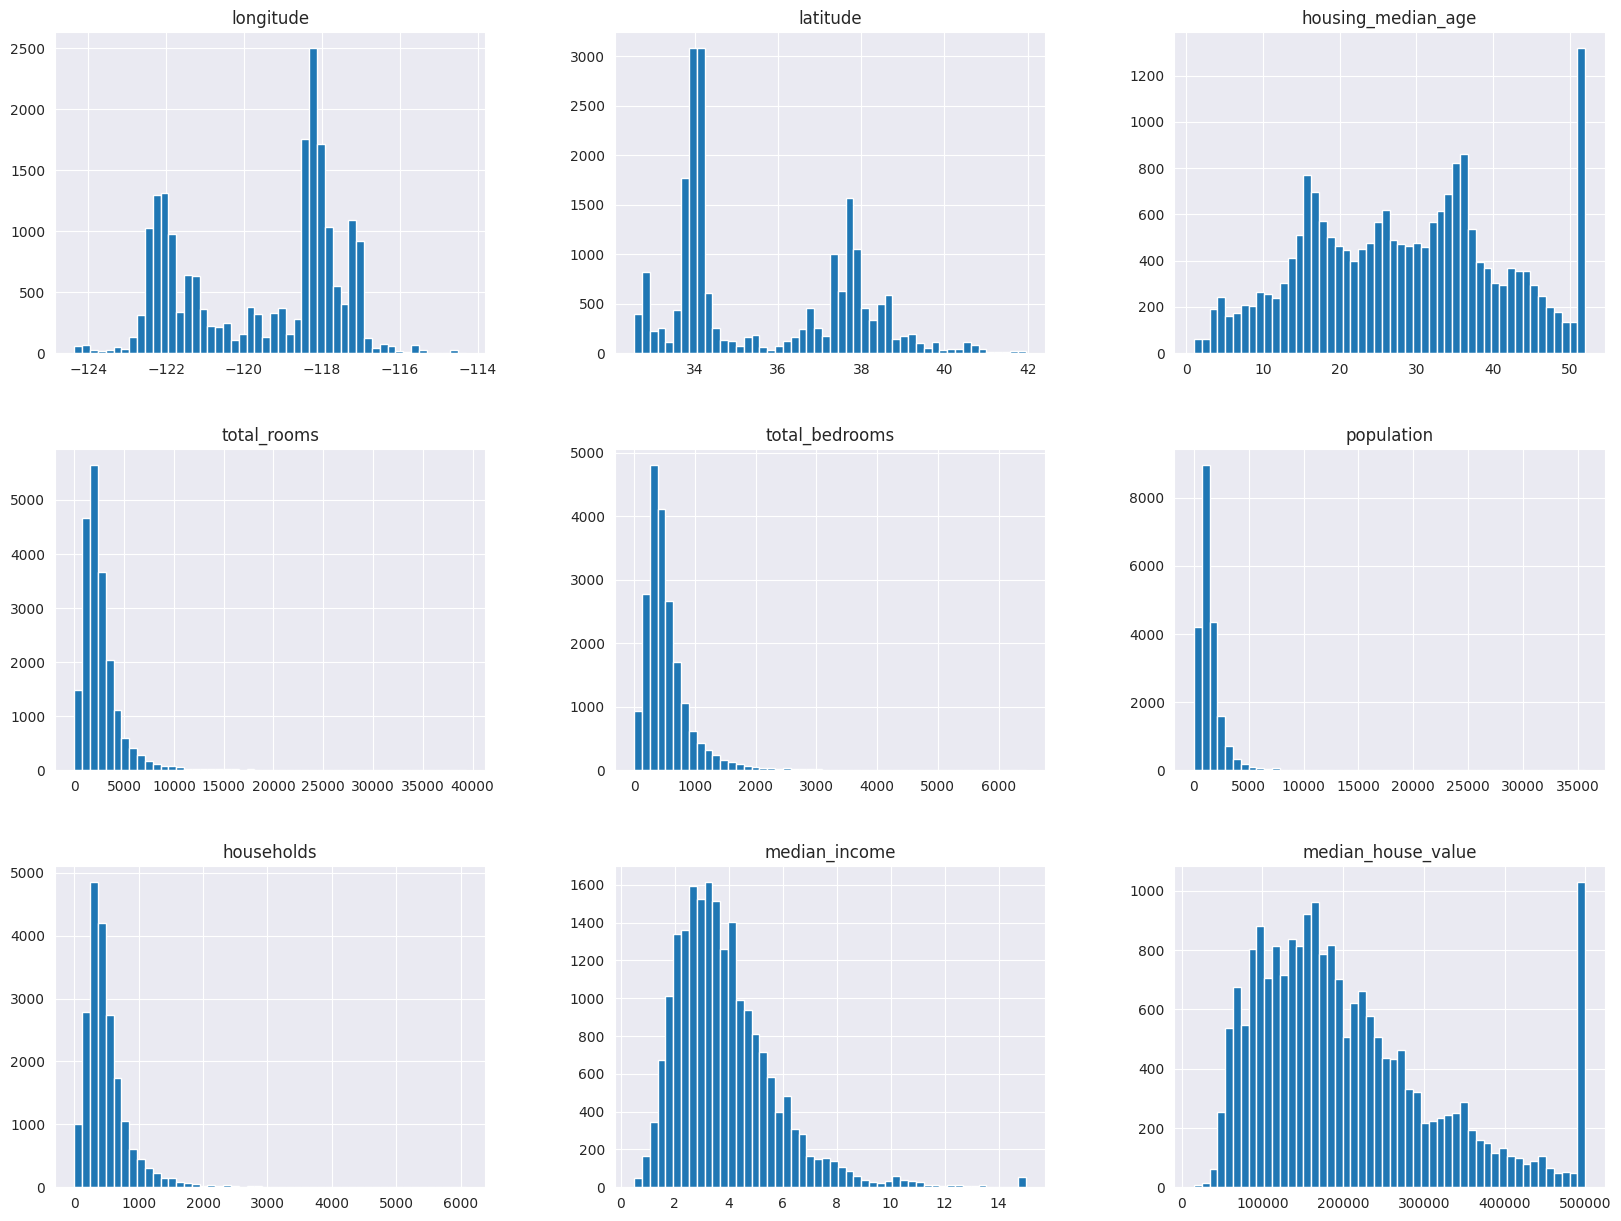

In [54]:
%matplotlib inline
import matplotlib.pyplot as plt

df.hist(bins=50, figsize=(20,15))
plt.show()

In [55]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

### Stratified Sampling based on Income Category

In [56]:
import numpy as np
# Create income category attribute
df["income_cat"] = pd.cut(df["median_income"],
                          bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                          labels=[1, 2, 3, 4, 5])


<Axes: >

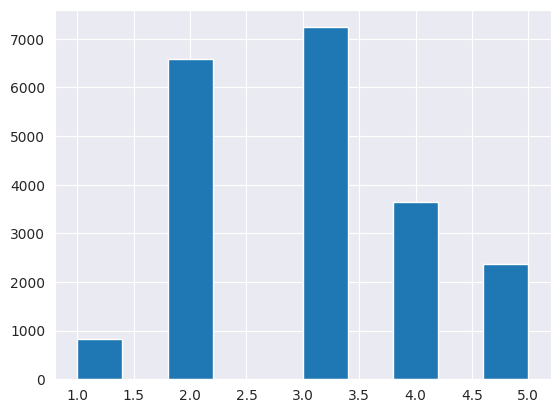

In [57]:
df["income_cat"].hist()

In [58]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]


In [59]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [60]:
df["income_cat"].value_counts() / len(df)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [61]:
df_num = df.drop("ocean_proximity", axis=1)

In [62]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

In [63]:
# Compare the income category proportions in the overall data, stratified test set, and random test set
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()

compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

In [64]:
# Comparison matrix between overall, stratified, and random sampling
compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [65]:
# Revert to original state by removing income_cat attribute
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### Visualizing Geographical Data

<Axes: xlabel='longitude', ylabel='latitude'>

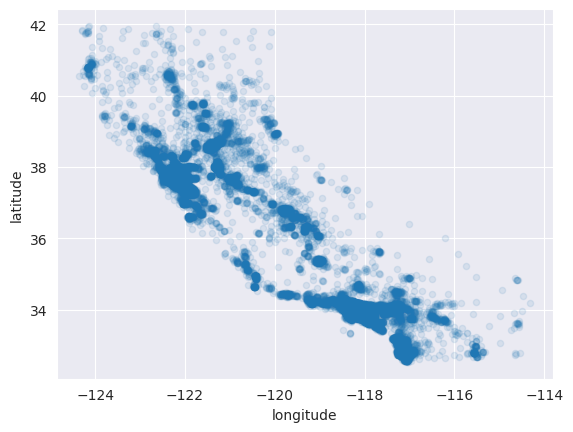

In [66]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

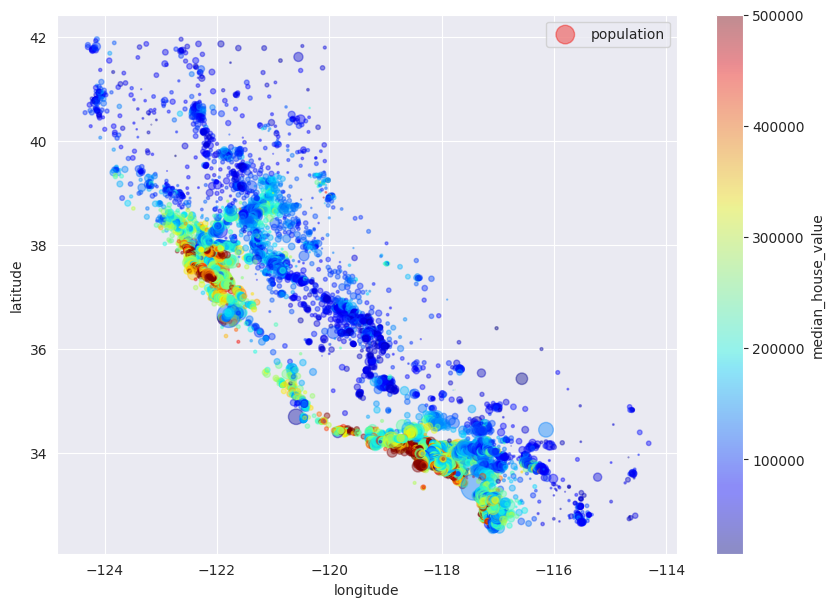

In [67]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
             s=df["population"]/100, label="population",
             c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
             figsize=(10,7))
plt.legend()

In [68]:
# Download the California image
images_path = os.path.join(PROJECT_ROOT_DIR, "images")
os.makedirs(images_path, exist_ok=True)
DOWNLOAD_ROOT = "https://raw.githubusercontent.com/ageron/handson-ml2/master/"
filename = "california.png"
print("Downloading", filename)
url = DOWNLOAD_ROOT + "images/end_to_end_project/" + filename
urllib.request.urlretrieve(url, os.path.join(images_path, filename))

('/home/jm/Documents/code/git/Machine_Learning/Projects/California_Housing/images/california.png',
 <http.client.HTTPMessage at 0x7f4a42c4d040>)

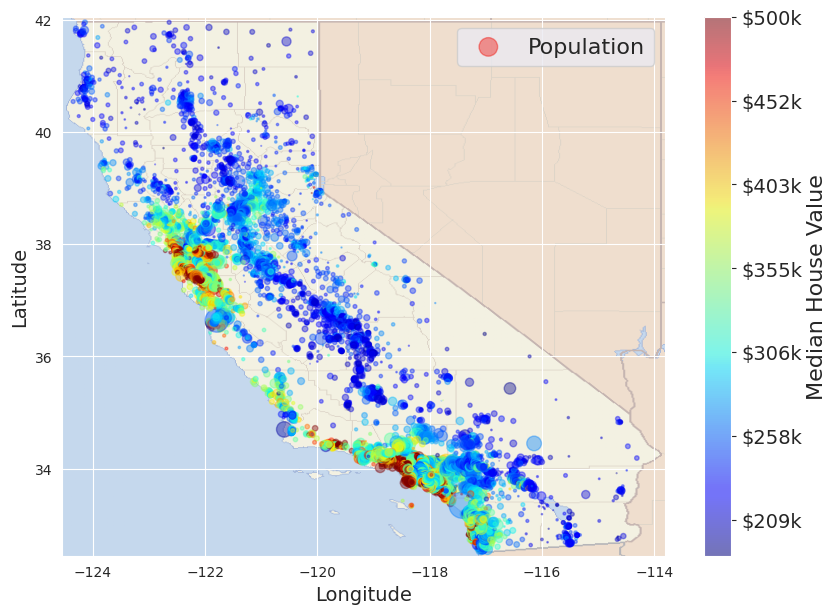

In [69]:
import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join(images_path, filename))
ax = df_num.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=df['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = df["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
plt.show()

In [70]:
corr_matrix = df_num.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
income_cat            0.643892
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

<Figure size 1200x800 with 0 Axes>

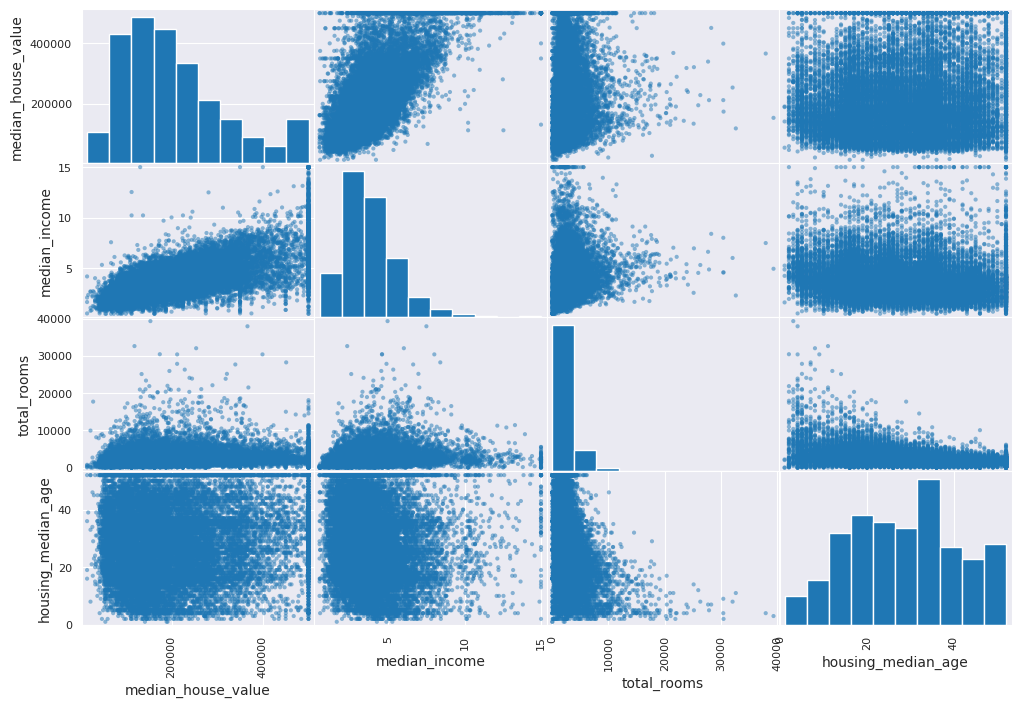

In [71]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms",
              "housing_median_age"]

plt.figure(figsize=(12,8)) 
scatter_matrix(df[attributes], figsize=(12,8))
plt.show()

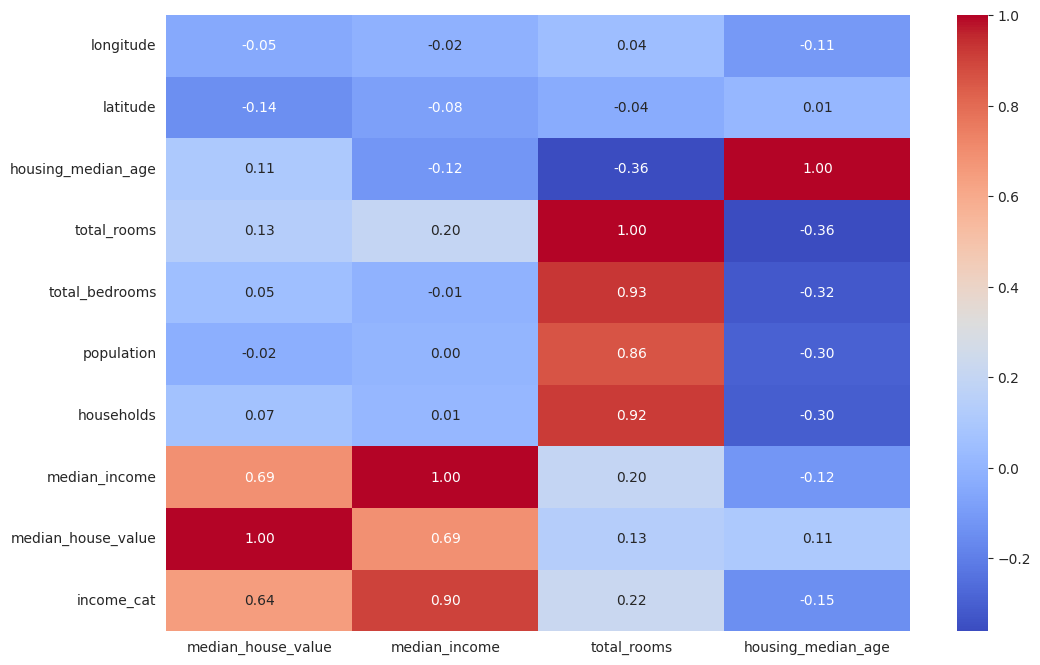

In [72]:
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix[attributes], annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

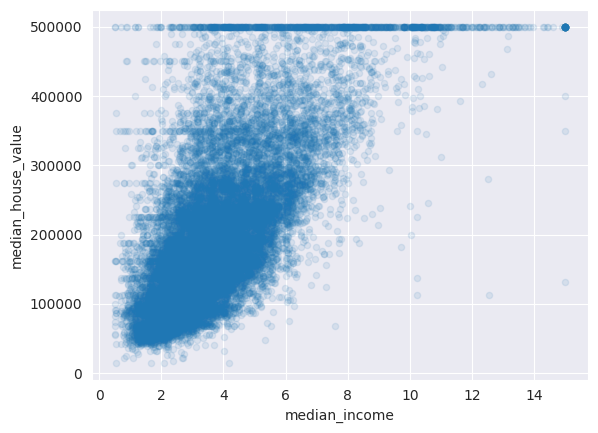

In [73]:
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

## Model Creation and Training

In [74]:
df_num = strat_train_set.drop("median_house_value", axis=1)
df_num = df_num.drop("ocean_proximity", axis=1)
labels = strat_train_set["median_house_value"].copy()
labels_test = strat_test_set["median_house_value"].copy()

### Cleaning the Data

In [75]:
# Find and replace missing values
df_num.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        158
population              0
households              0
median_income           0
dtype: int64

In [76]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
imputer.fit(df_num)

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [77]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [78]:
df_num.median().values

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [79]:
X = imputer.transform(df_num)

In [80]:
df_cat = df[["ocean_proximity"]]

In [81]:
df_cat

,ocean_proximity
0,NEAR BAY
1,NEAR BAY
2,NEAR BAY
3,NEAR BAY
4,NEAR BAY
...,...
20635,INLAND
20636,INLAND
20637,INLAND
20638,INLAND


In [82]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
df_cat_encoded = encoder.fit_transform(df_cat)
df_cat_encoded.toarray()

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(20640, 5))

In [83]:
encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [84]:
from sklearn.base import BaseEstimator, TransformerMixin
# Custom transformer to add combined attributes
class CombinedAttributesAdder(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rooms_per_household = X[:, 3] / X[:, 5]
        population_per_household = X[:, 4] / X[:, 5]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, 2] / X[:, 3]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('attribs_adder', CombinedAttributesAdder()),
    ('std_scaler', StandardScaler()),
])

In [86]:
from sklearn.compose import ColumnTransformer

num_attrs = list(df_num)
cat_attrs = ["ocean_proximity"]

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_attrs),
    ("cat", OneHotEncoder(), cat_attrs),
])

df_prepared = preprocessor.fit_transform(strat_train_set)
df_test_prepared = preprocessor.transform(strat_test_set)

In [87]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(df_prepared, labels)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Model Evaluation

In [88]:
from sklearn.metrics import mean_squared_error

train_pred = model.predict(df_prepared)
test_pred = model.predict(df_test_prepared)

train_mse = mean_squared_error(labels, train_pred)
test_mse = mean_squared_error(labels_test, test_pred)

In [89]:
train_mse

0.0

In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, df_prepared, labels,
                         scoring="neg_mean_squared_error", cv=10)
rmse_scores = np.sqrt(-scores)

In [91]:
def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(rmse_scores)

Scores: [69310.60459875 70816.55879239 66871.07248724 71293.91626119
 71256.12135761 70437.29076132 72409.90485632 70045.4499351
 69153.16794699 69293.98421225]
Mean: 70088.80712091574
Standard deviation: 1460.2029965446688


## Model Fine-Tuning

In [92]:
from sklearn.model_selection import GridSearchCV

param_distributions = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(model, param_distributions, cv=5,
                           scoring='neg_mean_squared_error',
                           return_train_score=True)

grid_search.fit(df_prepared, labels)

,estimator,DecisionTreeRegressor()
,param_grid,"{'max_depth': [None, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [93]:
final_model = grid_search.best_estimator_

In [94]:
x_test = strat_test_set.drop("median_house_value", axis=1)
y_test = strat_test_set["median_house_value"].copy()

x_test_prepared = preprocessor.transform(x_test)

In [95]:
final_test_predictions = final_model.predict(x_test_prepared)
final_train_predictions = final_model.predict(df_prepared)

final_mse = mean_squared_error(y_test, final_test_predictions)
final_rmse = np.sqrt(final_mse)

In [96]:
scores = cross_val_score(final_model, df_prepared, labels,
                         scoring="neg_mean_squared_error", cv=10)

In [97]:
display_scores(np.sqrt(-scores))

Scores: [60034.38202218 59615.9889665  55354.65369153 62318.74482271
 59358.14559419 61016.70761464 61496.23869976 60439.08068661
 57525.50428114 62934.95265226]
Mean: 60009.43990315076
Standard deviation: 2138.1731697786036


## Model Evaluation

In [98]:
train_comparison = pd.DataFrame({
    "Actual": labels,
    "Predicted": final_train_predictions
})

print("Training set comparison:")
print(train_comparison.head())

Training set comparison:
         Actual      Predicted
12655   72100.0   90901.587302
15502  279600.0  332537.500000
2908    82700.0   69816.666667
14053  112500.0  142028.125000
20496  238300.0  225239.465553


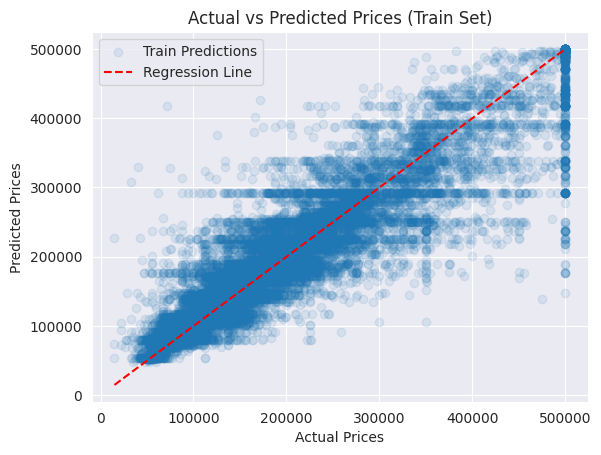

In [99]:
plt.scatter(labels, final_train_predictions, label='Train Predictions', alpha=0.1)
plt.plot([min(labels), max(labels)], [min(labels), max(labels)], color='red', linestyle='--', label='Regression Line')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices (Train Set)')
plt.legend()
plt.show()

In [100]:
from sklearn.metrics import r2_score

train_score = r2_score(labels, final_train_predictions)
print(f"Score on training set: {train_score:.4f}")

test_score = r2_score(y_test, final_test_predictions)
print(f"Score on test set: {test_score:.4f}")

Score on training set: 0.8258
Score on test set: 0.7435
